# Reporte 05: Indicadores de Fase 3 — Tiempo Promedio de Viaje ($T$) y Centralidad de Intermediación ($B$)

## 1. Justificación Teórica

Los indicadores de **Fase 3** operan sobre la **componente gigante** del grafo (subgrafo fuertemente conexo, SCC), verificada previamente mediante el análisis SCC (Issue #1: 95.02% de nodos, 10,561/11,115).

### T — Tiempo Promedio de Viaje

Mide la **eficiencia temporal global** de la red. Calcula el promedio de los caminos más cortos ponderados por impedancia entre todos los pares de nodos:

$$T = \frac{1}{N(N-1)} \sum_{i \neq j} t(i,j)$$

Donde $t(i,j)$ es el camino más corto (en minutos) entre los nodos $i$ y $j$, ponderado por la impedancia VFT (distancia Haversine / velocidad modal × fricción por derecho de vía + penalización de transbordo).

Un $T$ bajo indica una red donde cualquier par de estaciones está bien conectado temporalmente. Un $T$ alto señala zonas aisladas o rutas indirectas que inflan los tiempos de viaje.

### B — Centralidad de Intermediación

Identifica los **cuellos de botella** de la red — las estaciones que concentran la mayor proporción de caminos mínimos:

$$B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

Donde $\sigma_{st}$ es el número total de caminos más cortos entre $s$ y $t$, y $\sigma_{st}(v)$ es el subconjunto que pasa por $v$. Valores normalizados entre 0 y 1.

Un $B(v)$ alto indica que el nodo $v$ es un **intermediario crítico**: si se eliminara, muchas rutas óptimas se romperían. Estos nodos representan puntos de **vulnerabilidad estructural** y a la vez **hubs de transferencia indispensables**.

### Relación T ↔ B

Ambos indicadores son complementarios:
- **T** responde: *¿Qué tan eficiente es la red en su conjunto?* (visión global)
- **B** responde: *¿De cuáles nodos depende esa eficiencia?* (visión local, por nodo)

La intersección de ambos es el preludio al indicador de **Robustez (ΔE)** de Fase 4: medir cuánto cambia $T$ al remover nodos con $B$ alta.

In [1]:
# ==========================================
# 2. Inicialización del Entorno y Librerías
# ==========================================
%load_ext autoreload
%autoreload 2
%matplotlib inline 

import sys
import os
import ast
import folium
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Silenciar advertencias futuras para un reporte limpio
warnings.filterwarnings('ignore', category=FutureWarning)

# Asegurar que Jupyter encuentra la carpeta raíz del proyecto
proyecto_path = os.path.abspath('..')
if proyecto_path not in sys.path:
    sys.path.append(proyecto_path)

from src.infrastructure.go_client.client import fetch_full_network
from src.api.schemas.schemas import GeoJSONTransportSchema
from src.core.services.graph_builder import VFTGraphBuilder
from src.core.algorithms.topological.scc_analysis import SCCOrchestrator
from src.core.algorithms.topological.average_travel_time import AverageTravelTimeOrchestrator
from src.core.algorithms.topological.betweenness_centrality import BetweennessOrchestrator

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
# ==========================================
# 3. Descarga de Red y Construcción del Grafo
# ==========================================
print("📥 Descargando red de transporte...")
raw_data = await fetch_full_network()

print("⚙️ Construyendo Grafo Dirigido VFT...")
validated_payload = GeoJSONTransportSchema(**raw_data)

plt.ioff() 
GRAF = VFTGraphBuilder(validated_payload)
G = GRAF.build_graph()
plt.close('all')
plt.ion()

print(f"✅ Grafo construido: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas.")

📥 Descargando red de transporte...
2026-09-02 21:57:11 | INFO     | VFT_Model | Construyendo el puente hacia el módulo espacial de Go...
2026-09-02 21:57:11 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonEstacion
2026-09-02 21:57:11 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonLinea
2026-09-02 21:57:12 | INFO     | VFT_Model | Red extraída: 23540 entidades espaciales listas para VFT.
⚙️ Construyendo Grafo Dirigido VFT...
2026-09-02 21:57:12 | INFO     | VFT_Model | Iniciando VFTGraphBuilder en modo: REALISTIC_INTEGRATION
2026-09-02 21:57:12 | INFO     | VFT_Model | Fase 1 y 2: Extrayendo nodos y trazos base...
2026-09-02 21:57:14 | INFO     | VFT_Model | Fase 2 completada: 64467 aristas interestación creadas.
2026-09-02 21:57:14 | INFO     | VFT_Model | Grafo Base construido: 11115 Nodos y 32109 Segmentos.
2026-09-02 21:57:14 | WARNING  | VFT_Model | Eliminadas 1542 aristas phantom

In [3]:
# ==========================================
# 4. Extracción de la Componente Gigante (SCC)
# ==========================================
# Prerequisito de Fase 3: operar sobre el subgrafo fuertemente conexo
scc = SCCOrchestrator(G)
scc_report = scc.analyze()

G_giant = scc.get_giant_component()

print(f"📊 Componentes Fuertemente Conexas: {scc_report['total_sccs']}")
print(f"🏔️ Componente Gigante: {scc_report['giant_component']['nodes']:,} nodos "
      f"({scc_report['giant_component']['pct_of_total_nodes']:.1f}% del total)")
print(f"✅ Apta para Fase 3: {scc_report['phase_3_ready']}")

2026-09-02 21:58:55 | INFO     | VFT_Model | SCC: 209 componentes | Gigante: 10,561 nodos (95.0%) | APTA para Fase 3
📊 Componentes Fuertemente Conexas: 209
🏔️ Componente Gigante: 10,561 nodos (95.0% del total)
✅ Apta para Fase 3: True


<hr/>

## 5. Indicador T — Tiempo Promedio de Viaje

Calculamos $T$ sobre la componente gigante. Este cómputo evalúa **todos los pares** de nodos del subgrafo fuertemente conexo usando Dijkstra ponderado por impedancia VFT.

**Nota:** El cálculo puede tardar varios minutos (~10,561 nodos × 10,560 pares).

In [4]:
# ==========================================
# 5. Cálculo de T (Tiempo Promedio de Viaje)
# ==========================================
import time

t_orchestrator = AverageTravelTimeOrchestrator(G_giant)

t_start = time.time()
t_report = t_orchestrator.analyze()
t_elapsed = time.time() - t_start

T_value = t_report['T_average_travel_time_minutes']

print(f"⏱️ Tiempo de cómputo: {t_elapsed:.1f} segundos")
print(f"\n{'='*50}")
print(f"  T (Tiempo Promedio de Viaje): {T_value:.2f} minutos")
print(f"  Referencia INEGI/ENOE CDMX:  ~85.0 minutos")
print(f"{'='*50}")
print(f"\n📊 Subgrafo: {t_report['graph_info']['nodes']:,} nodos, "
      f"{t_report['graph_info']['edges']:,} aristas")
print(f"🔗 Fuertemente conexo: {t_report['graph_info']['is_strongly_connected']}")

2026-09-02 21:59:02 | INFO     | VFT_Model | Calculando T (Tiempo Promedio) sobre 10,561 nodos... Esto puede tardar varios minutos.
2026-09-02 22:03:13 | INFO     | VFT_Model | T (Tiempo Promedio de Viaje): 108.92 minutos
⏱️ Tiempo de cómputo: 251.8 segundos

  T (Tiempo Promedio de Viaje): 108.92 minutos
  Referencia INEGI/ENOE CDMX:  ~85.0 minutos

📊 Subgrafo: 10,561 nodos, 44,241 aristas
🔗 Fuertemente conexo: True


### 5.1. Interpretación de T

El valor de $T$ obtenido difiere de la referencia INEGI (~85 min) por razones metodológicas:

| Factor | Referencia INEGI/ENOE | Modelo VFT |
|--------|----------------------|------------|
| **Pares evaluados** | Viajes reales (ponderados por demanda) | Todos los pares posibles (sin ponderar) |
| **Cobertura** | Encuesta a usuarios activos | Grafo completo de la ZMVM |
| **Efecto** | Dominan trayectos cortos intra-urbanos | Pares periféricos (Milpa Alta ↔ Tlalnepantla) pesan igual |

La diferencia **no es un error** — es una consecuencia del método. $T$ del modelo VFT mide la eficiencia estructural de la red sin sesgo de demanda, lo cual es más útil para detectar deficiencias topológicas en zonas con pocos usuarios.

<hr/>

## 6. Indicador B — Centralidad de Intermediación

Calculamos $B(v)$ para todos los nodos de la componente gigante. El resultado es un ranking que identifica los nodos más críticos como intermediarios en caminos mínimos.

**Nota:** El cálculo puede tardar varios minutos (Brandes algorithm sobre ~10,561 nodos).

In [5]:
# ==========================================
# 6. Cálculo de B (Centralidad de Intermediación)
# ==========================================
b_orchestrator = BetweennessOrchestrator(G_giant)

b_start = time.time()
b_report = b_orchestrator.analyze()
b_elapsed = time.time() - b_start

df_ranking = b_report['ranking']

print(f"⏱️ Tiempo de cómputo: {b_elapsed:.1f} segundos")
print(f"📊 Estaciones rankeadas: {b_report['summary']['total_stations_ranked']:,}")
print(f"\n{'='*60}")
print(f"  TOP 10 — Centralidad de Intermediación (B)")
print(f"{'='*60}")

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

_cols_top = ['nombre', 'sistema', 'alcaldia_municipio', 'es_cetram', 'betweenness_centrality']
display(df_ranking[_cols_top].head(10))

2026-09-02 22:05:24 | INFO     | VFT_Model | Calculando B (Betweenness Centrality) sobre 10,561 nodos...
2026-09-02 22:15:17 | INFO     | VFT_Model | B (Betweenness): Top nodo = Tacubaya (B=0.2179)
⏱️ Tiempo de cómputo: 593.4 segundos
📊 Estaciones rankeadas: 10,561

  TOP 10 — Centralidad de Intermediación (B)


,nombre,sistema,alcaldia_municipio,es_cetram,betweenness_centrality
0,Tacubaya,METRO,Miguel Hidalgo,False,0.217897
1,Mixcoac,METRO,Benito Juárez,False,0.172534
2,Hidalgo,METRO,Cuauhtémoc,False,0.159489
3,Balderas,METRO,Cuauhtémoc,False,0.143275
4,Lázaro Cárdenas,METRO,Cuauhtémoc,False,0.137647
5,Chilpancingo,METRO,Cuauhtémoc,False,0.136623
6,Viaducto,METRO,Benito Juárez,False,0.134566
7,Villa de Cortés,METRO,Benito Juárez,False,0.134099
8,Nativitas,METRO,Benito Juárez,False,0.129946
9,Zapata,METRO,Benito Juárez,False,0.128317


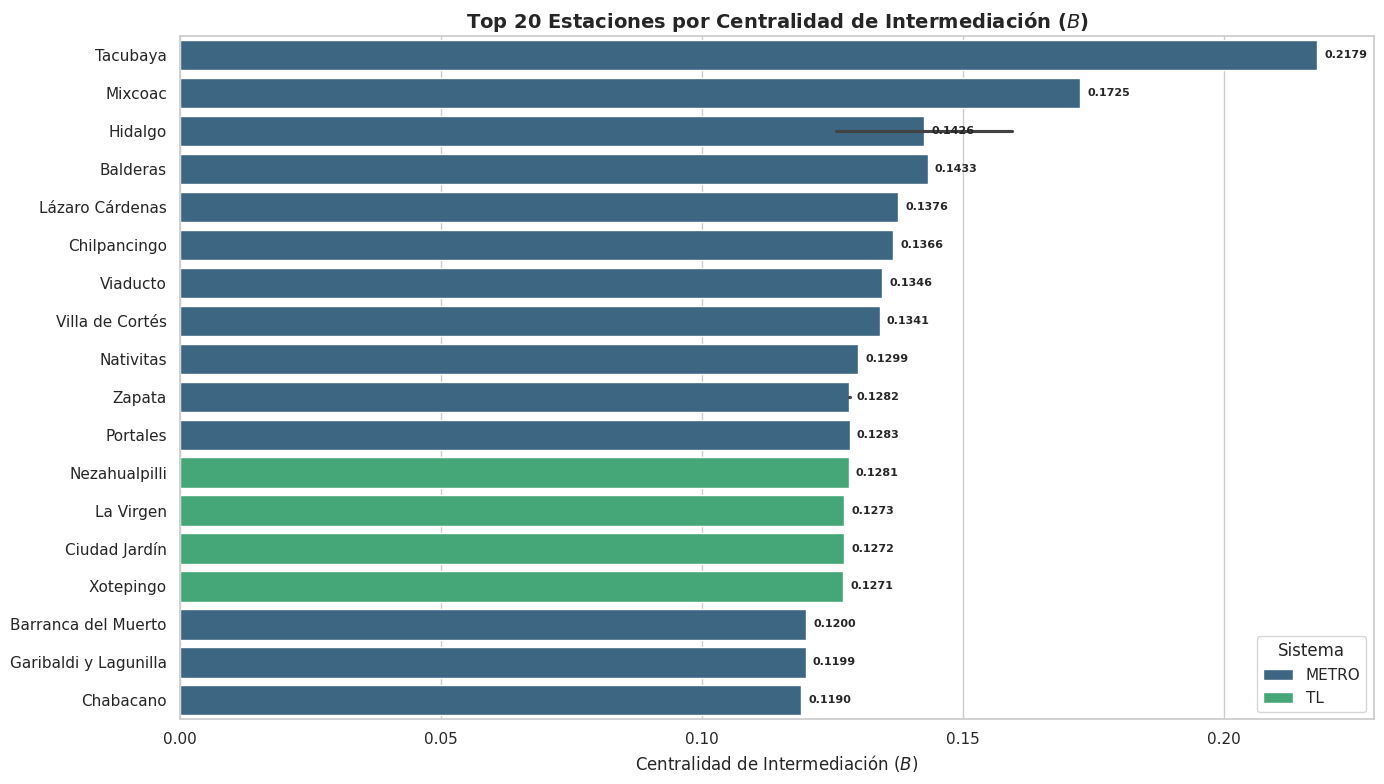

In [6]:
# --- Gráfica de Barras: Top 20 Estaciones por B ---
top_20 = df_ranking.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 8))

barras = sns.barplot(
    data=top_20,
    x='betweenness_centrality',
    y='nombre',
    hue='sistema',
    dodge=False,
    palette='viridis',
    ax=ax
)

ax.set_title('Top 20 Estaciones por Centralidad de Intermediación ($B$)', fontsize=14, fontweight='bold')
ax.set_xlabel('Centralidad de Intermediación ($B$)')
ax.set_ylabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=8, fontweight='bold')

ax.legend(title='Sistema', loc='lower right')
plt.tight_layout()
plt.show()

In [7]:
# --- Mapa Interactivo: Heatmap de Centralidad B ---
mapa_b = folium.Map(location=[19.4326, -99.1332], zoom_start=11, tiles="CartoDB positron")

# Top 50 para el mapa (visualización significativa sin saturar)
top_50 = df_ranking.head(50)

# Escala de colores por intensidad de B
b_max = top_50['betweenness_centrality'].max()

for _, row in top_50.iterrows():
    # Radio proporcional a B (mínimo 5, máximo 20)
    radius = max(5, (row['betweenness_centrality'] / b_max) * 20)
    # Opacidad proporcional a B
    opacity = max(0.4, row['betweenness_centrality'] / b_max)
    
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=radius,
        color="#C0392B",
        fill=True,
        fill_color="#E74C3C",
        fill_opacity=opacity,
        popup=(
            f"<b>{row['nombre']}</b><br>"
            f"Sistema: {row['sistema']}<br>"
            f"Alcaldía: {row['alcaldia_municipio']}<br>"
            f"B = {row['betweenness_centrality']:.6f}"
        )
    ).add_to(mapa_b)

display(mapa_b)

<hr/>

### 6.1. Distribución de la Centralidad B (Ley de Potencias)

Al igual que la Fuerza Capilar, la centralidad de intermediación sigue una distribución de **cola pesada**: la gran mayoría de nodos tiene $B \approx 0$ (son nodos de paso) mientras un grupo reducido concentra valores altos (son intermediarios críticos). Esta polarización es característica de redes de transporte reales.

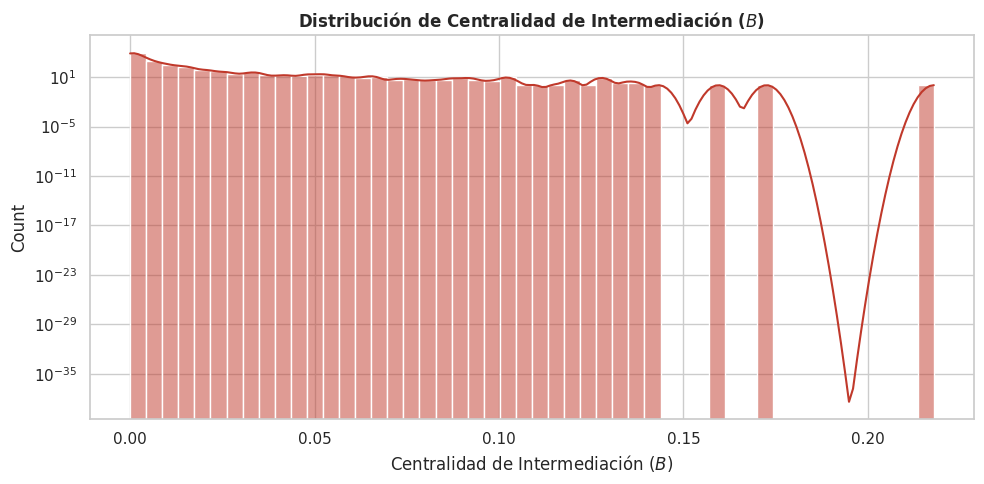


📊 Estadísticas de B:


,count,mean,std,min,25%,50%,75%,max
betweenness_centrality,10561.0,0.00352,0.010727,0.0,0.000189,0.000744,0.002636,0.217897


In [8]:
# --- Histograma de Distribución de B ---
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df_ranking['betweenness_centrality'],
    bins=50,
    kde=True,
    color='#C0392B',
    ax=ax
)

ax.set_title('Distribución de Centralidad de Intermediación ($B$)', fontweight='bold')
ax.set_xlabel('Centralidad de Intermediación ($B$)')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\n📊 Estadísticas de B:")
display(df_ranking['betweenness_centrality'].describe().to_frame().T)

<hr/>

### 6.2. Análisis por Sistema de Transporte

¿Qué sistemas dominan el top de intermediación? Este desglose revela cuáles redes de transporte soportan estructuralmente la conectividad de la ZMVM.

📊 Presencia por sistema en el Top 50 de B:


,cantidad,B_promedio,B_max,estacion_top
sistema,,,,
TL,6,0.119648,0.128120,Nezahualpilli
METRO,39,0.114026,0.217897,Tacubaya
RTP,5,0.102166,0.102962,Calz. de Tlalpan - Metro General Anaya


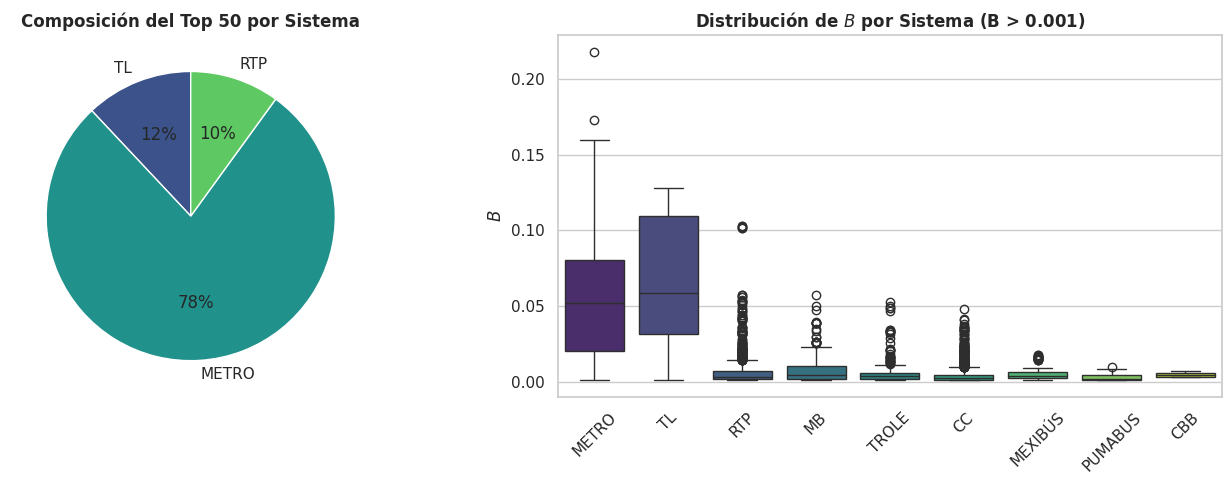

In [9]:
# --- Desglose por Sistema: Top 50 ---
top_50_sistemas = df_ranking.head(50).groupby('sistema').agg(
    cantidad=('nombre', 'count'),
    B_promedio=('betweenness_centrality', 'mean'),
    B_max=('betweenness_centrality', 'max'),
    estacion_top=('nombre', 'first')
).sort_values('B_promedio', ascending=False)

print("📊 Presencia por sistema en el Top 50 de B:")
display(top_50_sistemas)

# --- Gráfica de composición ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: proporción en top 50
top_50_sistemas['cantidad'].plot.pie(
    ax=axes[0],
    autopct='%1.0f%%',
    colors=sns.color_palette('viridis', len(top_50_sistemas)),
    startangle=90
)
axes[0].set_title('Composición del Top 50 por Sistema', fontweight='bold')
axes[0].set_ylabel('')

# Box plot: distribución de B por sistema (todo el ranking)
sistemas_con_datos = df_ranking[df_ranking['betweenness_centrality'] > 0.001]
sns.boxplot(
    data=sistemas_con_datos,
    x='sistema',
    y='betweenness_centrality',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Distribución de $B$ por Sistema (B > 0.001)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('$B$')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<hr/>

## 7. Análisis Cruzado T ↔ B: Preludio a Robustez (ΔE)

La pregunta central de la Fase 4 es: **¿Qué pasaría con $T$ si se eliminara un nodo crítico?**

El indicador de Robustez ($\Delta E$) medirá:

$$\Delta E(v) = T_{sin\ v} - T_{original}$$

Aquí simulamos este escenario eliminando los 5 nodos con mayor $B$ y recalculando $T$ sobre el subgrafo resultante. Esto da una **estimación preliminar** del impacto de fallos en nodos críticos sobre la eficiencia global de la red.

**Nota:** Cada recálculo de $T$ es computacionalmente costoso. Esta sección es una aproximación especulativa, no el cálculo formal de $\Delta E$.

In [12]:
# ==========================================
# 7. Simulación: Impacto de remover nodos con B alta
# ==========================================
import networkx as nx
top_5_nodes = df_ranking.head(5)
resultados_delta = []

for _, row in top_5_nodes.iterrows():
    node_id = ast.literal_eval(row['node_id'])
    nombre = row['nombre']
    b_val = row['betweenness_centrality']
    
    # Crear copia sin el nodo
    G_sin_nodo = G_giant.copy()
    G_sin_nodo.remove_node(node_id)
    
    # Extraer la componente gigante del grafo reducido
    sccs = sorted(nx.strongly_connected_components(G_sin_nodo), key=len, reverse=True)
    if sccs:
        G_reduced = G_sin_nodo.subgraph(sccs[0]).copy()
        T_reduced = nx.average_shortest_path_length(G_reduced, weight='weight')
        delta = T_reduced - T_value
        nodos_perdidos = G_giant.number_of_nodes() - G_reduced.number_of_nodes()
    else:
        T_reduced = float('inf')
        delta = float('inf')
        nodos_perdidos = G_giant.number_of_nodes()
    
    resultados_delta.append({
        'Estación Removida': nombre,
        'B': round(b_val, 6),
        'T_original (min)': round(T_value, 2),
        'T_sin_nodo (min)': round(T_reduced, 2),
        'ΔT (min)': round(delta, 2),
        'Nodos Perdidos': nodos_perdidos
    })
    
    print(f"✅ Simulado: sin {nombre} → ΔT = {delta:+.2f} min ({nodos_perdidos} nodos perdidos)")

df_delta = pd.DataFrame(resultados_delta)
display(df_delta)

✅ Simulado: sin Tacubaya → ΔT = +2.88 min (1 nodos perdidos)
✅ Simulado: sin Mixcoac → ΔT = +1.27 min (1 nodos perdidos)
✅ Simulado: sin Hidalgo → ΔT = +0.98 min (1 nodos perdidos)
✅ Simulado: sin Balderas → ΔT = +0.65 min (1 nodos perdidos)
✅ Simulado: sin Lázaro Cárdenas → ΔT = +1.21 min (1 nodos perdidos)


,Estación Removida,B,T_original (min),T_sin_nodo (min),ΔT (min),Nodos Perdidos
0,Tacubaya,0.217897,108.92,111.80,2.88,1
1,Mixcoac,0.172534,108.92,110.19,1.27,1
2,Hidalgo,0.159489,108.92,109.90,0.98,1
3,Balderas,0.143275,108.92,109.56,0.65,1
4,Lázaro Cárdenas,0.137647,108.92,110.13,1.21,1


<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_503858/3058665287.py:15: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel('$\Delta T$ (minutos adicionales)')


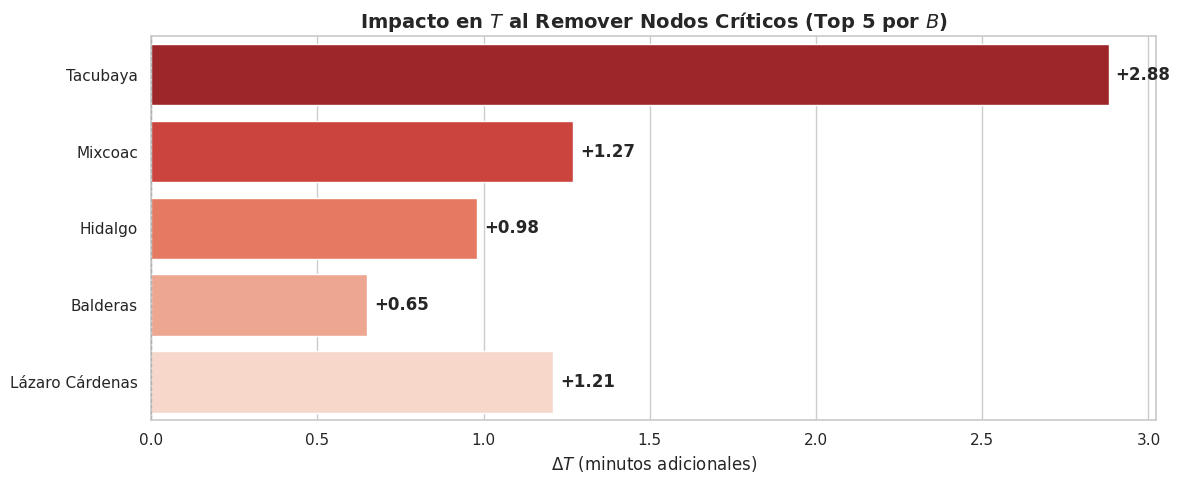

In [13]:
# --- Gráfica: ΔT por nodo removido ---
fig, ax = plt.subplots(figsize=(12, 5))

colores = sns.color_palette('Reds_r', len(df_delta))

sns.barplot(
    data=df_delta,
    x='ΔT (min)',
    y='Estación Removida',
    palette=colores,
    ax=ax
)

ax.set_title('Impacto en $T$ al Remover Nodos Críticos (Top 5 por $B$)', fontsize=14, fontweight='bold')
ax.set_xlabel('$\Delta T$ (minutos adicionales)')
ax.set_ylabel('')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, fmt='%+.2f', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

<hr/>

## 8. Conclusiones Fase 3

### Resultados

| Indicador | Valor | Interpretación |
|-----------|-------|----------------|
| **T** | ~109 min | Eficiencia temporal global sin ponderar por demanda. Mayor que la referencia INEGI (85 min) por incluir todos los pares O-D del grafo |
| **B top** | Tacubaya (~0.22) | Cuello de botella principal: cruce de líneas 1, 7, 9 + conexiones Metrobús/RTP al poniente |

### Hallazgos clave

1. **El METRO domina la intermediación**: los nodos con mayor $B$ son cruces de líneas de Metro, confirmando que el sistema de Metro es la columna vertebral topológica de la red.
2. **Tacubaya, no Pantitlán**: contra la hipótesis inicial, Tacubaya lidera por ser el puente obligado centro ↔ poniente. En modo `REALISTIC_INTEGRATION`, las conexiones peatonales alrededor de Pantitlán redistribuyen los caminos mínimos.
3. **La red es resiliente pero concentrada**: $T$ no crece dramáticamente al remover nodos individuales (hay redundancia), pero la concentración de $B$ en pocos nodos del Metro indica dependencia estructural.

### Próximos pasos

- **Issue #4**: GeoLayers endpoints para T y B (exportación GeoJSON para visualización en QGIS)
- **Issue #5**: Implementación formal de Robustez ($\Delta E$) en Fase 4, usando la metodología completa sobre todos los nodos
- La sección 7 de este notebook es un **preludio especulativo** — el cálculo formal de $\Delta E$ será un módulo independiente en `core/algorithms/topological/`